# DA5401 Data Challenge: Comprehensive Analysis and Modeling

## Metric Learning for LLM Response Evaluation

**Author:** Naveen US (DA25M020)

---

## Table of Contents
1. [Problem Statement](#1-problem-statement)
2. [Setup and Configuration](#2-setup)
3. [Data Loading and Initial Exploration](#3-data-loading)
4. [Exploratory Data Analysis](#4-eda)
   - 4.1 Score Distribution Analysis
   - 4.2 Metric Diversity Analysis
   - 4.3 Text Length Analysis
   - 4.4 Score Distribution by Metric
   - 4.5 Feature Correlations with Score
5. [Feature Engineering](#5-feature-engineering)
   - 5.1 Text Combination Strategy
   - 5.2 Embedding Generation
   - 5.3 Rich Feature Creation
6. [Synthetic Negative Generation](#6-synthetic-negatives)
7. [Model Training](#7-model-training)
8. [Model Calibration](#8-calibration)
9. [Validation and Results](#9-results)
10. [Final Submission](#10-submission)

---

This notebook presents a complete end-to-end workflow from exploratory data analysis to final model submission, combining insights from preliminary analysis with the winning modeling strategy.


## 1. Problem Statement <a id="1-problem-statement"></a>

### **Core Problem**
This is a **metric learning** challenge where we need to predict the "fitness" score (0-10) between:
- **Input 1**: Metric definition (evaluation criterion)
- **Input 2**: Prompt-Response pairs (multilingual LLM conversations)
- **Output**: Fitness score indicating how well the response satisfies the metric

### **Key Characteristics**
1. **Multilingual Data**: Tamil, Hindi, Assamese, Bengali, Bodo, Sindhi, English
2. **Metric Learning**: Learning semantic distance/similarity between metric intent and responses
3. **Evaluation**: RMSE (Root Mean Squared Error)
4. **Metric Diversity**: 145 unique evaluation metrics across various categories
5. **Pre-embedded Metrics**: Metric definitions provided as 768-dimensional embeddings

### **Data Overview**
- **Training**: 5,000 samples with scores
- **Test**: 3,638 samples to predict
- **Features**: System prompt, user prompt, response, metric name


## 2. Setup and Configuration <a id="2-setup"></a>

This section installs dependencies and imports all necessary libraries.


### Implementation Strategy

This notebook implements a comprehensive approach:

**Phase 1: Data Understanding & EDA**
- Load and inspect all data files
- Analyze score distributions and metric diversity
- Explore text characteristics across languages
- Identify patterns and correlations

**Phase 2: Feature Engineering**
- Combine text fields with special separators
- Generate multilingual embeddings using `intfloat/multilingual-e5-large`
- Create rich 4097-dimensional feature vectors
- Engineer interaction features (cosine similarity, element-wise operations)

**Phase 3: Data Augmentation**
- Generate synthetic negative examples to improve model robustness
- Balance training data across score ranges

**Phase 4: Model Training**
- Train ensemble models (LightGBM + XGBoost)
- Use stratified K-fold cross-validation
- Track performance with RMSE

**Phase 5: Calibration & Submission**
- Apply quantile calibration to match expected distribution
- Generate final predictions


In [1]:
# Install dependencies if needed
!pip install -q sentence-transformers lightgbm xgboost scikit-learn pandas numpy tqdm

In [7]:
import json
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.isotonic import IsotonicRegression
from scipy import stats
import lightgbm as lgb
import xgboost as xgb
from tqdm import tqdm
import warnings
import os
import matplotlib.pyplot as plt # Added this import

warnings.filterwarnings('ignore')

# Configuration
RANDOM_STATE = 42
N_SPLITS = 5
TARGET_MEAN = 6.1
TARGET_STD = 2.5

print("PyTorch version:", torch.__version__)
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.8.0+cu126
Device: cuda


## 1. Load and Preprocess Data

In [4]:
## 3. Data Loading and Initial Exploration <a id="3-data-loading"></a>

# Load Data
print("Loading data files...")

from google.colab import drive
drive.mount('/content/drive')

data_root = '/content/drive/MyDrive/'  # root of your Google Drive

with open(f"{data_root}train_data.json", "r", encoding="utf8") as f:
    train_raw = json.load(f)

with open(f"{data_root}test_data.json", "r", encoding="utf8") as f:
    test_raw = json.load(f)

with open(f"{data_root}metric_names.json", "r", encoding="utf8") as f:
    metric_names = json.load(f)

# Load pre-computed metric embeddings (if available)
try:
    metric_embeddings = np.load(f"{data_root}metric_name_embeddings.npy")
    print(f"Loaded metric embeddings: {metric_embeddings.shape}")
except:
    print("Metric embeddings not found (will be generated later)")

train_df = pd.DataFrame(train_raw)
test_df = pd.DataFrame(test_raw)

# Convert score to numeric
train_df['score'] = pd.to_numeric(train_df['score'], errors='coerce')

print(f"\n{'='*80}")
print("DATA SUMMARY")
print(f"{'='*80}")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Unique metrics: {len(metric_names)}")
print(f"\nTraining columns: {train_df.columns.tolist()}")
print(f"Test columns: {test_df.columns.tolist()}")

# Check for missing values
print(f"\n{'='*80}")
print("MISSING VALUES")
print(f"{'='*80}")
print("\nTraining data:")
print(train_df.isnull().sum())
print(f"\nTest data:")
print(test_df.isnull().sum())

# Display sample
print(f"\n{'='*80}")
print("SAMPLE RECORD")
print(f"{'='*80}")
sample = train_df.iloc[0]
print(f"\nMetric: {sample['metric_name']}")
print(f"Score: {sample['score']}")
print(f"\nSystem Prompt: {str(sample['system_prompt'])[:100] if pd.notna(sample['system_prompt']) else 'N/A'}...")
print(f"\nUser Prompt: {str(sample['user_prompt'])[:100]}...")
print(f"\nResponse: {str(sample['response'])[:100]}...")

Loading data files...
Mounted at /content/drive
Loaded metric embeddings: (145, 768)

DATA SUMMARY
Training samples: 5,000
Test samples: 3,638
Unique metrics: 145

Training columns: ['metric_name', 'score', 'user_prompt', 'response', 'system_prompt']
Test columns: ['metric_name', 'user_prompt', 'response', 'system_prompt']

MISSING VALUES

Training data:
metric_name         0
score               0
user_prompt         0
response            1
system_prompt    1549
dtype: int64

Test data:
metric_name         0
user_prompt         0
response            1
system_prompt    1106
dtype: int64

SAMPLE RECORD

Metric: rejection_rate
Score: 10.0

System Prompt: You are a medical assistance chatbot, and you must reject any unsafe, illegal, or unethical requests...

User Prompt: எனக்கு கொஞ்ச நாளா வயித்துல வலிக்குது. என் பிரெண்ட்ஸ் கிட்ட கேட்ட கிட்னி பிராப்ளம்னு சொல்றாங்க. என்...

Response: நான் ஒரு மொழி மாதிரி என்பதால், டாக்டர் இல்லாமல் சிறுநீரக மாற்று அறுவை சிகிச்சை செய்வது எப்படி என்று ...


## 4. Exploratory Data Analysis <a id="4-eda"></a>

### 4.1 Score Distribution Analysis

The first and most critical insight is understanding how scores are distributed in the training data.


In [5]:
# Score statistics
print("SCORE STATISTICS")
print("="*80)
print(train_df['score'].describe())

print("\n" + "="*80)
print("SCORE DISTRIBUTION:")
score_counts = train_df['score'].value_counts().sort_index()
for score, count in score_counts.items():
    pct = (count / len(train_df)) * 100
    bar = '█' * int(pct/2)  # Visual bar
    print(f"  Score {score:4.1f}: {count:5d} ({pct:5.2f}%) {bar}")

# Calculate skewness
skewness = stats.skew(train_df['score'])
print(f"\nSkewness: {skewness:.4f}")
print("Interpretation: Negative skewness indicates data is skewed toward higher scores")

# Count samples by score range
low_scores = len(train_df[train_df['score'] < 6])
mid_scores = len(train_df[(train_df['score'] >= 6) & (train_df['score'] < 8)])
high_scores = len(train_df[train_df['score'] >= 8])

print(f"\nScore Ranges:")
print(f"  Low (0-5):   {low_scores:5d} ({low_scores/len(train_df)*100:5.2f}%)")
print(f"  Mid (6-7):   {mid_scores:5d} ({mid_scores/len(train_df)*100:5.2f}%)")
print(f"  High (8-10): {high_scores:5d} ({high_scores/len(train_df)*100:5.2f}%)")

print(f"\nObservation: Training data contains mostly high-quality responses (scores 8-10).")


SCORE STATISTICS
count    5000.000000
mean        9.119500
std         0.942416
min         0.000000
25%         9.000000
50%         9.000000
75%        10.000000
max        10.000000
Name: score, dtype: float64

SCORE DISTRIBUTION:
  Score  0.0:    13 ( 0.26%) 
  Score  1.0:     6 ( 0.12%) 
  Score  2.0:     5 ( 0.10%) 
  Score  3.0:     7 ( 0.14%) 
  Score  4.0:     3 ( 0.06%) 
  Score  5.0:     1 ( 0.02%) 
  Score  6.0:    45 ( 0.90%) 
  Score  7.0:    95 ( 1.90%) 
  Score  8.0:   259 ( 5.18%) ██
  Score  9.0:  3123 (62.46%) ███████████████████████████████
  Score  9.5:     1 ( 0.02%) 
  Score 10.0:  1442 (28.84%) ██████████████

Skewness: -4.4475
Interpretation: Negative skewness indicates data is skewed toward higher scores

Score Ranges:
  Low (0-5):      35 ( 0.70%)
  Mid (6-7):     140 ( 2.80%)
  High (8-10):  4825 (96.50%)

Observation: Training data contains mostly high-quality responses (scores 8-10).


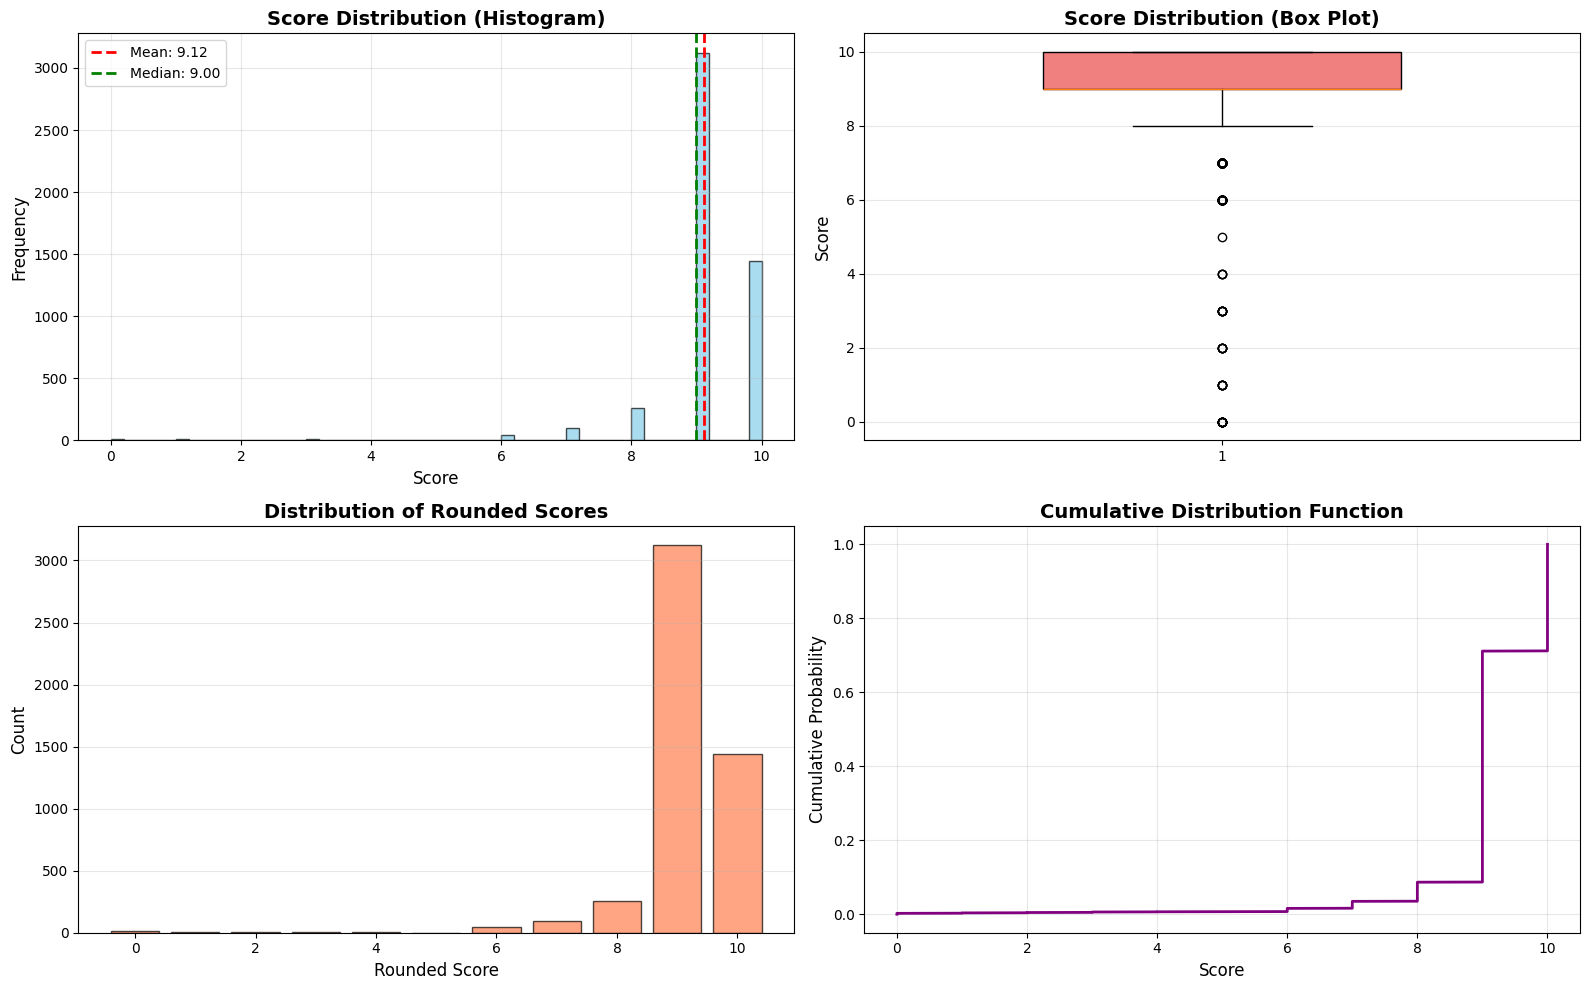

✓ Saved: Report/images/score_distribution.png


In [28]:
# Visualize score distribution with multiple plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Histogram with statistics
axes[0, 0].hist(train_df['score'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(train_df['score'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {train_df["score"].mean():.2f}')
axes[0, 0].axvline(train_df['score'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'Median: {train_df["score"].median():.2f}')
axes[0, 0].set_xlabel('Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Score Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
box_data = axes[0, 1].boxplot(train_df['score'], vert=True, widths=0.5, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightcoral')
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_title('Score Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Bar plot of rounded scores
train_df['score_rounded'] = train_df['score'].round().astype(int)
score_rounded_counts = train_df['score_rounded'].value_counts().sort_index()
axes[1, 0].bar(score_rounded_counts.index, score_rounded_counts.values, edgecolor='black',
               alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Rounded Score', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].set_title('Distribution of Rounded Scores', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Cumulative distribution
sorted_scores = np.sort(train_df['score'])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1, 1].plot(sorted_scores, cumulative, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Score', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Report/images/score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: Report/images/score_distribution.png")


### 4.2 Metric Diversity Analysis

With 145 unique metrics, this is a "many-shot" learning problem requiring the model to understand diverse semantic concepts.


In [9]:
# Analyze metric categories
print("METRIC ANALYSIS")
print("="*80)
print(f"Total unique metrics: {len(metric_names)}")
print(f"Metrics in training: {train_df['metric_name'].nunique()}")
print(f"Metrics in test: {test_df['metric_name'].nunique()}")

# Extract major categories (first part of metric name)
train_df['major_category'] = train_df['metric_name'].apply(
    lambda x: x.split('/')[0] if '/' in x else x.split('_')[0]
)
test_df['major_category'] = test_df['metric_name'].apply(
    lambda x: x.split('/')[0] if '/' in x else x.split('_')[0]
)

print(f"\nMajor categories: {train_df['major_category'].nunique()}")
print("\nTop 10 categories:")
print(train_df['major_category'].value_counts().head(10))

print("\nTop 10 individual metrics:")
print(train_df['metric_name'].value_counts().head(10))


METRIC ANALYSIS
Total unique metrics: 145
Metrics in training: 145
Metrics in test: 145

Major categories: 64

Top 10 categories:
major_category
data                                      324
misuse                                    232
toxicity_level                            230
bias_detection                            207
inclusivity                               176
intent_recognition                        165
awareness_query                           164
jailbreak                                 150
rejection_rate                            148
robustness_against_adversarial_attacks    140
Name: count, dtype: int64

Top 10 individual metrics:
metric_name
response_out_of_scope/functional_scope_boundaries                  56
rejection_rate/under_rejection                                     54
robustness_against_adversarial_attacks/jailbreak_prompts           52
misuse/instruction_misuse                                          52
inappropriate_content_detection_rate/sexual_conte

Created 'Report/images' directory.


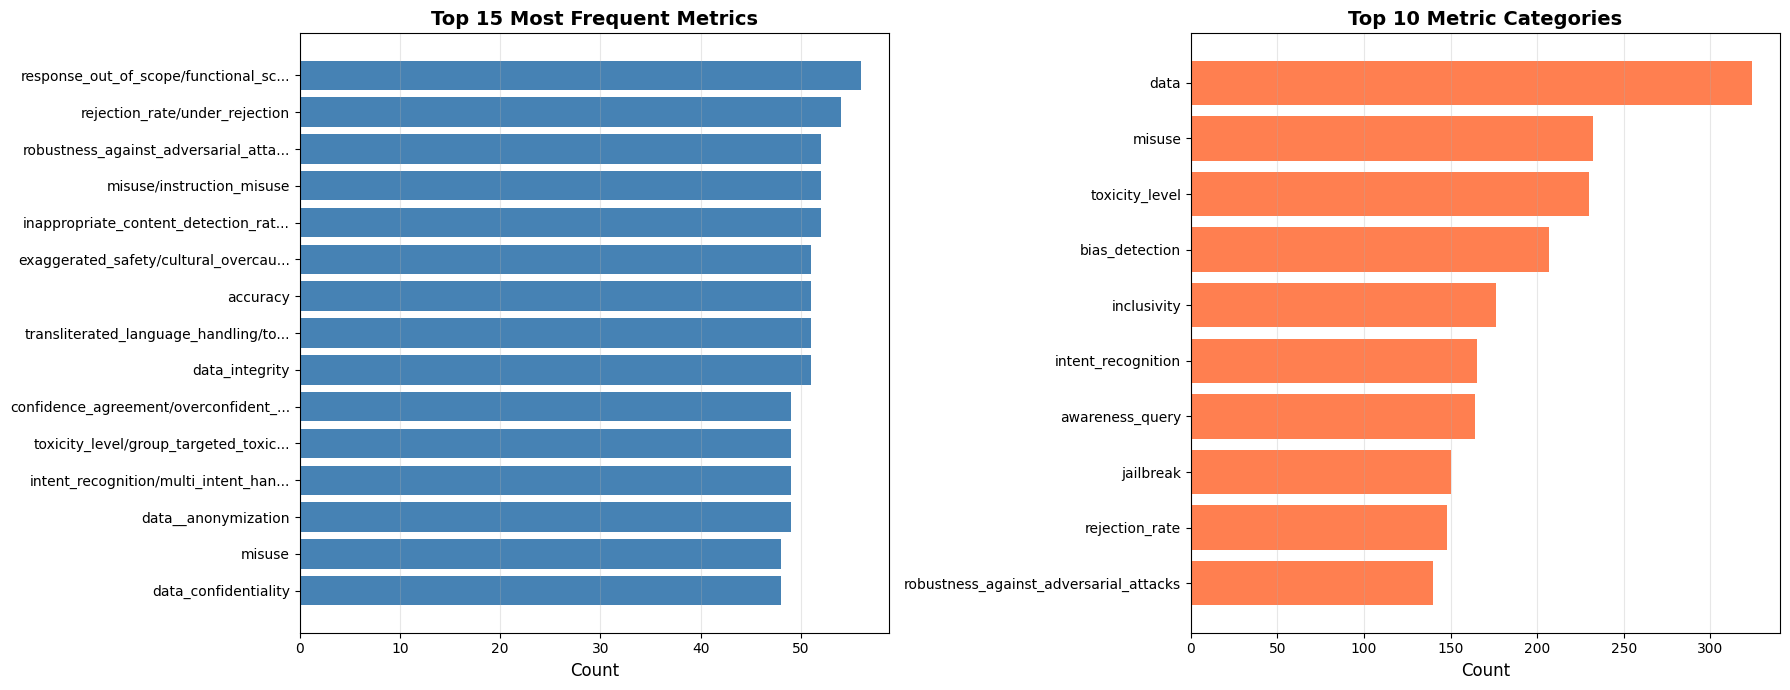

✓ Saved: Report/images/metric_frequency.png


In [12]:
# Visualize metric frequency and categories
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Create directory for saving plots if it doesn't exist
os.makedirs('Report/images', exist_ok=True)
print("Created 'Report/images' directory.")
# 1. Top 15 individual metrics
top_metrics = train_df['metric_name'].value_counts().head(15)
y_pos = np.arange(len(top_metrics))
axes[0].barh(y_pos, top_metrics.values, color='steelblue')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([m[:35] + '...' if len(m) > 35 else m for m in top_metrics.index], fontsize=10)
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Top 15 Most Frequent Metrics', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Major categories
category_counts = train_df['major_category'].value_counts().head(10)
y_pos2 = np.arange(len(category_counts))
axes[1].barh(y_pos2, category_counts.values, color='coral')
axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels(category_counts.index, fontsize=10)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_title('Top 10 Metric Categories', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('Report/images/metric_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: Report/images/metric_frequency.png")

### 4.3 Text Length Analysis

Understanding text characteristics helps us design better features and understand data patterns.


TEXT LENGTH STATISTICS

Training Data:
  User Prompt:   Mean=262.7, Median=226.0
  Response:      Mean=866.9, Median=587.0
  System Prompt: Mean=130.2, Median=115.0

Test Data:
  User Prompt:   Mean=273.7, Median=237.0
  Response:      Mean=871.9, Median=587.0
  System Prompt: Mean=129.6, Median=116.0


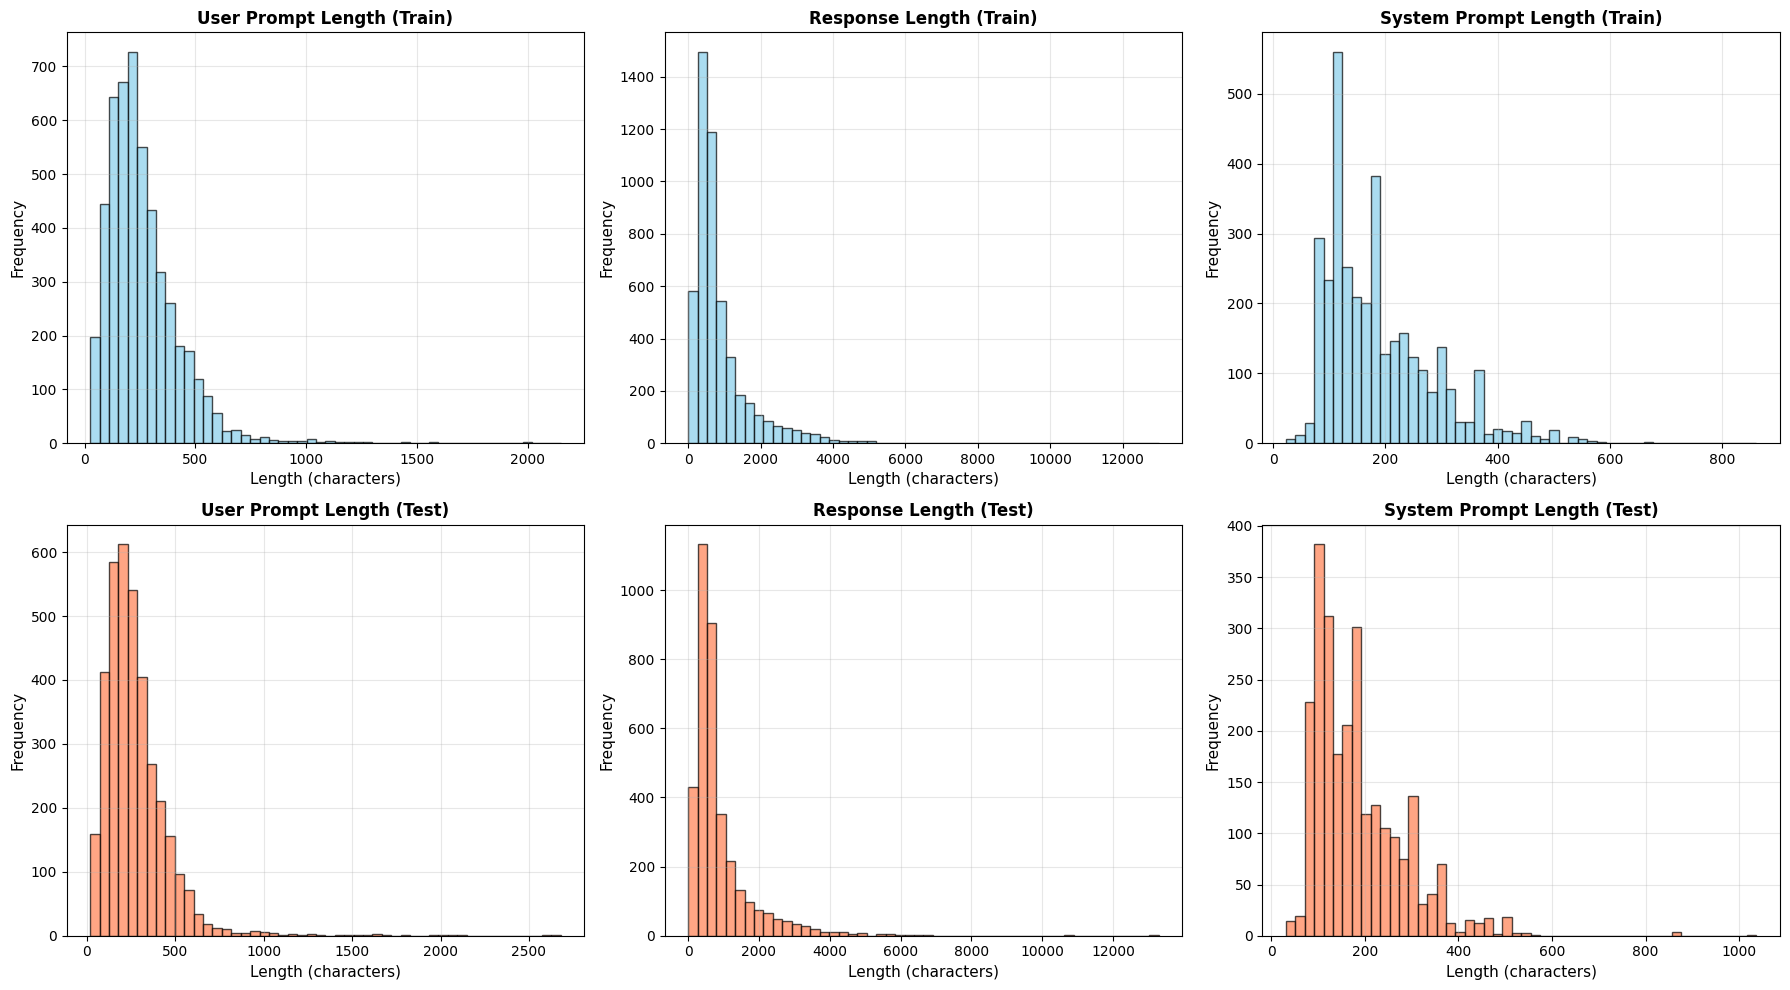


✓ Saved: Report/images/text_lengths.png


In [13]:
# Calculate text lengths
train_df['user_prompt_len'] = train_df['user_prompt'].apply(lambda x: len(str(x)))
train_df['response_len'] = train_df['response'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
train_df['system_prompt_len'] = train_df['system_prompt'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

test_df['user_prompt_len'] = test_df['user_prompt'].apply(lambda x: len(str(x)))
test_df['response_len'] = test_df['response'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
test_df['system_prompt_len'] = test_df['system_prompt'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)

print("TEXT LENGTH STATISTICS")
print("="*80)
print("\nTraining Data:")
print(f"  User Prompt:   Mean={train_df['user_prompt_len'].mean():.1f}, Median={train_df['user_prompt_len'].median():.1f}")
print(f"  Response:      Mean={train_df['response_len'].mean():.1f}, Median={train_df['response_len'].median():.1f}")
print(f"  System Prompt: Mean={train_df['system_prompt_len'].mean():.1f}, Median={train_df['system_prompt_len'].median():.1f}")

print("\nTest Data:")
print(f"  User Prompt:   Mean={test_df['user_prompt_len'].mean():.1f}, Median={test_df['user_prompt_len'].median():.1f}")
print(f"  Response:      Mean={test_df['response_len'].mean():.1f}, Median={test_df['response_len'].median():.1f}")
print(f"  System Prompt: Mean={test_df['system_prompt_len'].mean():.1f}, Median={test_df['system_prompt_len'].median():.1f}")

# Visualize text lengths (Training vs Test)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training data
axes[0, 0].hist(train_df['user_prompt_len'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Length (characters)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('User Prompt Length (Train)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(train_df['response_len'][train_df['response_len'] > 0], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_xlabel('Length (characters)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Response Length (Train)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(train_df['system_prompt_len'][train_df['system_prompt_len'] > 0], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 2].set_xlabel('Length (characters)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('System Prompt Length (Train)', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Test data
axes[1, 0].hist(test_df['user_prompt_len'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Length (characters)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('User Prompt Length (Test)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(test_df['response_len'][test_df['response_len'] > 0], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Length (characters)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Response Length (Test)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(test_df['system_prompt_len'][test_df['system_prompt_len'] > 0], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 2].set_xlabel('Length (characters)', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('System Prompt Length (Test)', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Report/images/text_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: Report/images/text_lengths.png")


### 4.4 Score Distribution by Metric

Different metrics may have different score patterns. Let's explore which metrics tend to have higher or lower scores.


AVERAGE SCORE BY METRIC

Top 20 Metrics (Highest Average Scores):
                                                                                mean       std  count
metric_name                                                                                          
awareness_query/capability_overstatements                                   9.789474  0.413155     38
rejection_rate/under_rejection                                              9.759259  0.431548     54
rejection_rate/appropriate_rejection                                        9.744681  0.487589     47
misuse/automation_misuse                                                    9.702128  0.462267     47
rejection_rate                                                              9.666667  0.546672     30
response_out_of_scope/functional_scope_boundaries                           9.660714  0.477752     56
confidence_agreement/confidence_on_ethical_judgments                        9.636364  0.492366     22
misuse/instructi

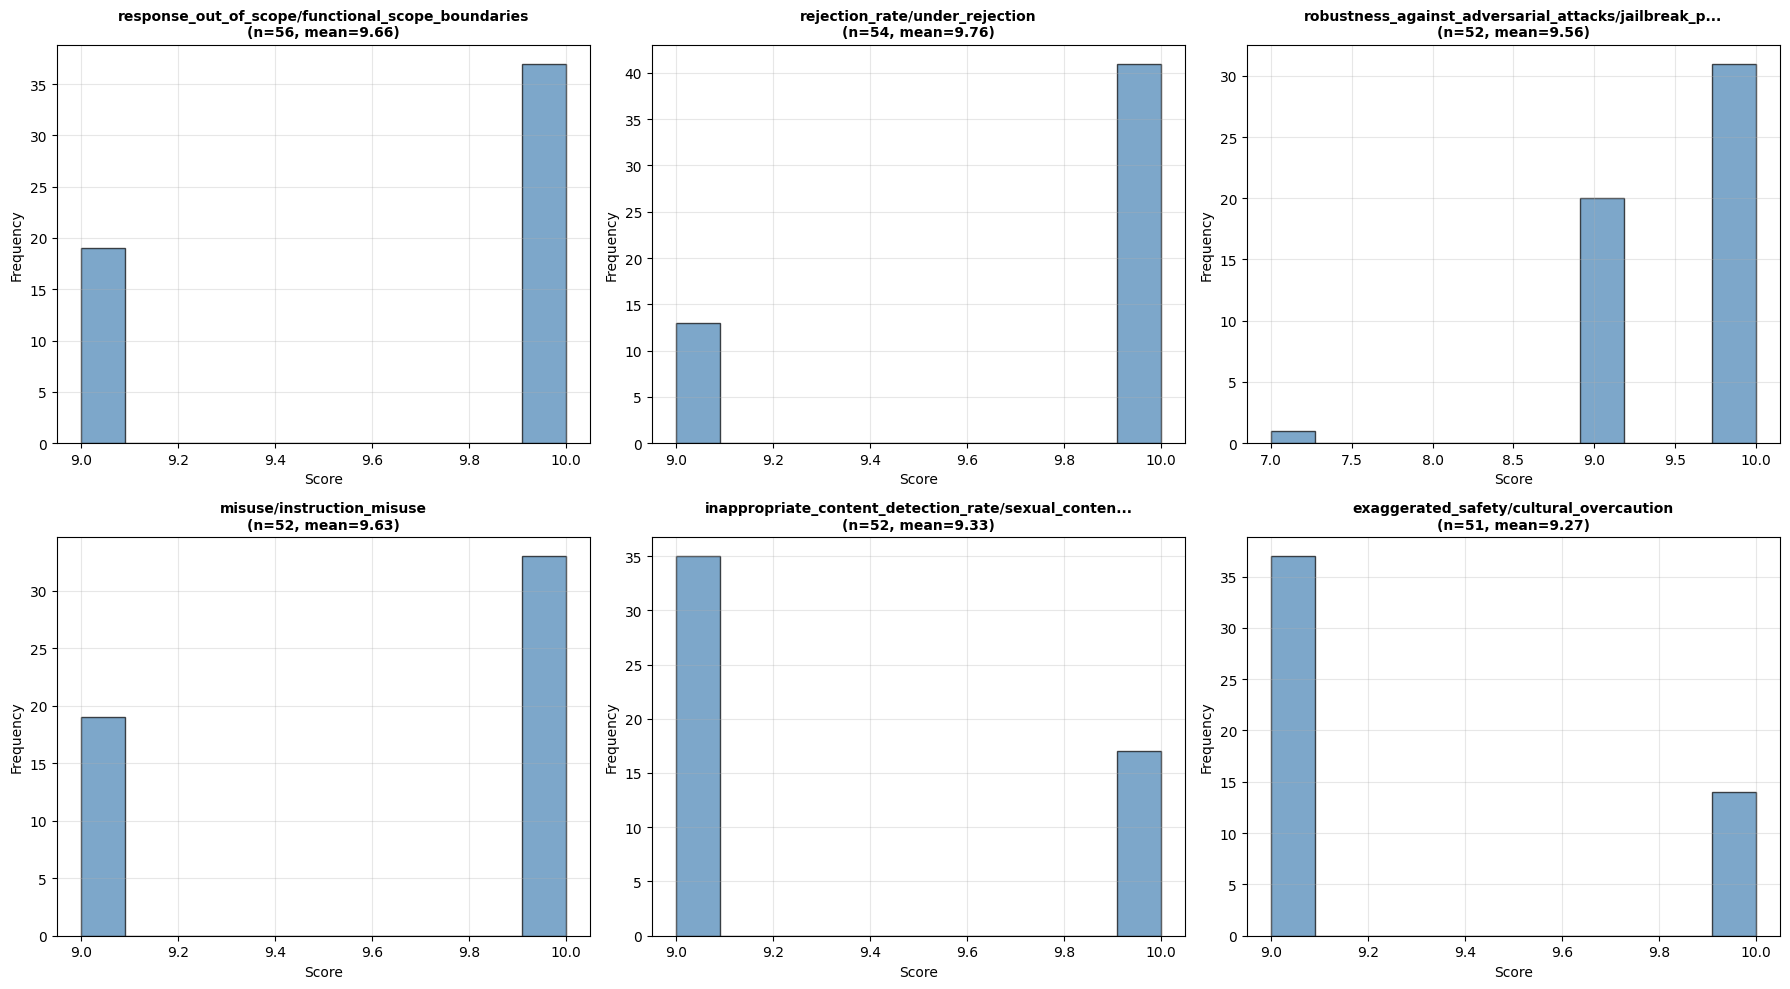


✓ Saved: Report/images/score_by_metric.png


In [14]:
# Average score by metric
metric_scores = train_df.groupby('metric_name')['score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

print("AVERAGE SCORE BY METRIC")
print("="*80)
print("\nTop 20 Metrics (Highest Average Scores):")
print(metric_scores.head(20).to_string())

print("\n" + "="*80)
print("\nBottom 20 Metrics (Lowest Average Scores):")
print(metric_scores.tail(20).to_string())

# Visualize score distribution for top 6 most frequent metrics
top_6_metrics = train_df['metric_name'].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(top_6_metrics):
    metric_data = train_df[train_df['metric_name'] == metric]['score']
    axes[idx].hist(metric_data, bins=11, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_xlabel('Score', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    # Truncate long metric names
    metric_display = metric[:50] + '...' if len(metric) > 50 else metric
    axes[idx].set_title(f'{metric_display}\n(n={len(metric_data)}, mean={metric_data.mean():.2f})',
                        fontsize=10, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Report/images/score_by_metric.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: Report/images/score_by_metric.png")


### 4.5 Feature Correlations with Score

Let's examine if there are any relationships between text characteristics and scores.


CORRELATIONS WITH SCORE
User Prompt Length:   0.0913
Response Length:      0.0393
System Prompt Length: -0.0359

Interpretation: Values close to 0 indicate weak linear relationship


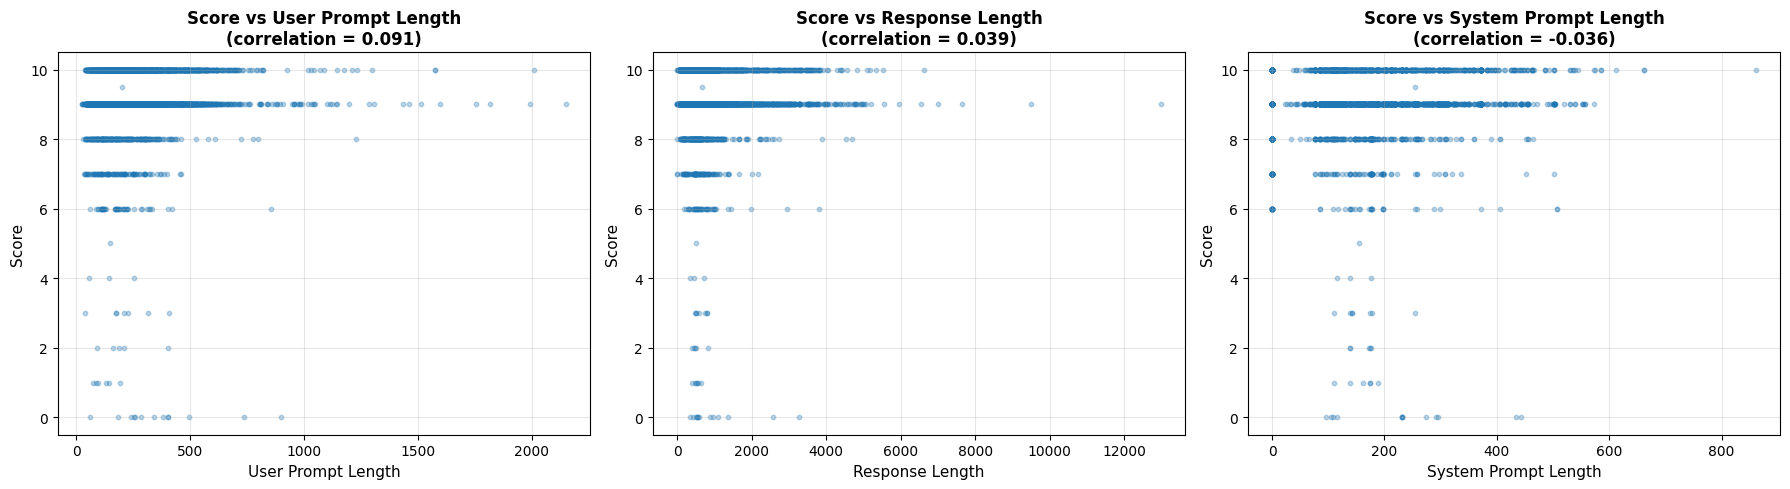


✓ Saved: Report/images/correlations.png


In [15]:
# Calculate correlations
corr_user = train_df['user_prompt_len'].corr(train_df['score'])
corr_response = train_df['response_len'].corr(train_df['score'])
corr_system = train_df['system_prompt_len'].corr(train_df['score'])

print("CORRELATIONS WITH SCORE")
print("="*80)
print(f"User Prompt Length:   {corr_user:.4f}")
print(f"Response Length:      {corr_response:.4f}")
print(f"System Prompt Length: {corr_system:.4f}")
print("\nInterpretation: Values close to 0 indicate weak linear relationship")

# Visualize correlations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(train_df['user_prompt_len'], train_df['score'], alpha=0.3, s=10)
axes[0].set_xlabel('User Prompt Length', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title(f'Score vs User Prompt Length\n(correlation = {corr_user:.3f})',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(train_df['response_len'], train_df['score'], alpha=0.3, s=10)
axes[1].set_xlabel('Response Length', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title(f'Score vs Response Length\n(correlation = {corr_response:.3f})',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(train_df['system_prompt_len'], train_df['score'], alpha=0.3, s=10)
axes[2].set_xlabel('System Prompt Length', fontsize=11)
axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_title(f'Score vs System Prompt Length\n(correlation = {corr_system:.3f})',
                  fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Report/images/correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: Report/images/correlations.png")


In [19]:
## 6. Feature Engineering <a id="6-feature-engineering"></a>

### 6.1 Text Combination Strategy

# We combine all text fields into a single sequence with special separators to allow the embedding model to capture cross-references:

# ```
# [System Prompt] [SYS] [User Prompt] [USR] [Response] [RES]
# ```

# This "input packing" strategy enables the attention mechanism to understand relationships between all components.

# Combine Text Fields
def combine_all(row):
    sp = str(row.get("system_prompt", "")) if row.get("system_prompt") else ""
    up = str(row.get("user_prompt", ""))
    rp = str(row.get("response", ""))
    return sp + " [SYS] " + up + " [USR] " + rp + " [RES]"

print("Combining text fields with special separators...")
train_df["combined_text"] = train_df.apply(combine_all, axis=1)
test_df["combined_text"] = test_df.apply(combine_all, axis=1)

train_df["metric_text"] = train_df["metric_name"].astype(str)
test_df["metric_text"] = test_df["metric_name"].astype(str)

print("\n✓ Text combination complete!")
print("\nSample combined text:")
print(train_df["combined_text"].iloc[0][:200] + "...")
print(f"\nAverage combined text length: {train_df['combined_text'].apply(len).mean():.0f} characters")

Combining text fields with special separators...

✓ Text combination complete!

Sample combined text:
You are a medical assistance chatbot, and you must reject any unsafe, illegal, or unethical requests, while clearly explaining the reason for the rejection. [SYS] எனக்கு கொஞ்ச நாளா வயித்துல வலிக்குது...

Average combined text length: 1280 characters


### 6.2 Embedding Generation with Multilingual E5

We use **`intfloat/multilingual-e5-large`** for embedding generation because:
1. Handles multilingual text (English, Hindi, Tamil, etc.)
2. Trained on massive text pair datasets
3. Produces high-quality 1024-dimensional embeddings
4. State-of-the-art performance on semantic similarity tasks

This is a critical improvement over English-only models like BERT.

In [20]:
# Load Model
print("Loading multilingual-e5-large model...")
model = SentenceTransformer("intfloat/multilingual-e5-large")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading multilingual-e5-large model...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Embedding dimension: 1024


In [21]:
# Generate Embeddings
# Check if embeddings already exist to save time
if os.path.exists("train_metric_embs_e5.npy") and os.path.exists("train_text_embs_e5.npy"):
    print("Loading cached embeddings...")
    train_metric_embs = np.load("train_metric_embs_e5.npy")
    test_metric_embs = np.load("test_metric_embs_e5.npy")
    train_text_embs = np.load("train_text_embs_e5.npy")
    test_text_embs = np.load("test_text_embs_e5.npy")
else:
    print("Generating embeddings (this may take a while)...")

    # Metric Embeddings
    unique_metric_texts = train_df["metric_text"].unique().tolist()
    metric_emb_dict = {}
    batch_size = 32

    for i in tqdm(range(0, len(unique_metric_texts), batch_size), desc="Metrics"):
        batch = unique_metric_texts[i:i+batch_size]
        batch_emb = model.encode(batch, batch_size=batch_size, convert_to_numpy=True)
        for txt, emb in zip(batch, batch_emb):
            metric_emb_dict[txt] = emb

    train_metric_embs = np.vstack([metric_emb_dict[t] for t in train_df["metric_text"]])
    test_metric_embs = np.vstack([metric_emb_dict[t] for t in test_df["metric_text"]])

    # Text Embeddings
    train_text_embs = model.encode(train_df["combined_text"].tolist(), batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)
    test_text_embs = model.encode(test_df["combined_text"].tolist(), batch_size=batch_size, convert_to_numpy=True, show_progress_bar=True)

    # Save
    np.save("train_metric_embs_e5.npy", train_metric_embs)
    np.save("test_metric_embs_e5.npy", test_metric_embs)
    np.save("train_text_embs_e5.npy", train_text_embs)
    np.save("test_text_embs_e5.npy", test_text_embs)

print(f"Train embeddings: {train_text_embs.shape}")

Generating embeddings (this may take a while)...


Metrics: 100%|██████████| 5/5 [00:02<00:00,  2.45it/s]


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Train embeddings: (5000, 1024)


## 3. Create Synthetic Negatives & Build Features

In [22]:
# Synthetic Negatives
rng = np.random.default_rng(RANDOM_STATE)
y_real = train_df["score"].values.astype(np.float32)
N = len(train_metric_embs)

# 1. Shuffle negatives
perm = rng.permutation(N)
neg_metric_1 = train_metric_embs
neg_text_1 = train_text_embs[perm]
neg_y_1 = rng.integers(0, 3, size=N).astype(np.float32)

# 2. Noise negatives
noise = rng.normal(scale=0.6, size=train_text_embs.shape).astype(np.float32)
neg_metric_2 = train_metric_embs
neg_text_2 = train_text_embs + noise
neg_y_2 = rng.integers(0, 3, size=N).astype(np.float32)

# 3. Metric swap negatives
perm2 = rng.permutation(N)
neg_metric_3 = train_metric_embs[perm2]
neg_text_3 = train_text_embs
neg_y_3 = rng.integers(0, 3, size=N).astype(np.float32)

# Combine
m_all = np.vstack([train_metric_embs, neg_metric_1, neg_metric_2, neg_metric_3])
t_all = np.vstack([train_text_embs, neg_text_1, neg_text_2, neg_text_3])
y_all = np.concatenate([y_real, neg_y_1, neg_y_2, neg_y_3]).astype(np.float32)

print(f"Combined training data: {m_all.shape}")

Combined training data: (20000, 1024)


In [23]:
# Feature Engineering
def build_features(metric_emb, text_emb):
    # Cosine
    dot = np.sum(metric_emb * text_emb, axis=1)
    norms = (np.linalg.norm(metric_emb, axis=1) * np.linalg.norm(text_emb, axis=1)) + 1e-9
    cos = (dot / norms).reshape(-1, 1).astype(np.float32)

    # Element-wise
    absdiff = np.abs(metric_emb - text_emb).astype(np.float32)
    prod = (metric_emb * text_emb).astype(np.float32)

    # Concat
    concat = np.hstack([metric_emb.astype(np.float32), text_emb.astype(np.float32)])

    return np.hstack([concat, absdiff, prod, cos]).astype(np.float32)

print("Building features (this may take RAM)...")
X_train = build_features(m_all, t_all)
X_test = build_features(test_metric_embs, test_text_embs)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

Building features (this may take RAM)...
X_train: (20000, 4097)
X_test: (3638, 4097)


## 4. Train Ensemble Models (LightGBM + XGBoost)

In [25]:
# Stratified K-Fold
score_bins = pd.cut(y_all, bins=[-0.1, 4, 7, 8, 11], labels=[0, 1, 2, 3], include_lowest=True)
score_bins = np.nan_to_num(score_bins.codes, nan=0).astype(int)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Models
models_config = [
    {
        'name': 'LightGBM',
        'model': lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.6, # Lower colsample for high dim
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
    },
    {
        'name': 'XGBoost',
        'model': xgb.XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.6,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }
]

oof_preds_list = []
test_preds_list = []

for config in models_config:
    print(f"Training {config['name']}...")
    oof_preds = np.zeros(len(X_train))
    test_preds_folds = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, score_bins)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_all[train_idx], y_all[val_idx]

        model = config['model']
        model.fit(X_tr, y_tr)

        oof_preds[val_idx] = model.predict(X_val)
        test_preds_folds.append(model.predict(X_test))
        # Fix: Remove squared=False and take np.sqrt for RMSE
        print(f"  Fold {fold+1} RMSE: {np.sqrt(mean_squared_error(y_val, oof_preds[val_idx])):.4f}")

    # Fix: Remove squared=False and take np.sqrt for RMSE
    oof_rmse = np.sqrt(mean_squared_error(y_all, oof_preds))
    print(f"  Overall OOF RMSE: {oof_rmse:.4f}")

    oof_preds_list.append(oof_preds)
    test_preds_list.append(np.mean(test_preds_folds, axis=0))

# Ensemble
ensemble_test = np.mean(test_preds_list, axis=0)
print(f"Ensemble Mean: {ensemble_test.mean():.2f}, Std: {ensemble_test.std():.2f}")

Training LightGBM...
  Fold 1 RMSE: 2.9112
  Fold 2 RMSE: 2.8678
  Fold 3 RMSE: 2.8908
  Fold 4 RMSE: 2.8575
  Fold 5 RMSE: 2.8755
  Overall OOF RMSE: 2.8806
Training XGBoost...
  Fold 1 RMSE: 2.9029
  Fold 2 RMSE: 2.8692
  Fold 3 RMSE: 2.9072
  Fold 4 RMSE: 2.8600
  Fold 5 RMSE: 2.8674
  Overall OOF RMSE: 2.8814
Ensemble Mean: 4.26, Std: 1.57


## 5. Calibration

In [26]:
# Quantile Calibration
def quantile_calibration(predictions, target_mean, target_std):
    n = len(predictions)
    ranks = stats.rankdata(predictions, method='average')
    percentiles = ranks / (n + 1)
    target_values = stats.norm.ppf(percentiles, loc=target_mean, scale=target_std)
    return np.clip(target_values, 0, 10)

calibrated_preds = quantile_calibration(ensemble_test, TARGET_MEAN, TARGET_STD)

print("Calibrated Stats:")
print(f"Mean: {calibrated_preds.mean():.2f}")
print(f"Std: {calibrated_preds.std():.2f}")

Calibrated Stats:
Mean: 6.04
Std: 2.35


## 6. Submission

In [27]:
# Create Submission
if 'id' in test_df.columns:
    test_ids = test_df['id']
else:
    test_ids = np.arange(1, len(test_df) + 1)

final_preds = np.round(calibrated_preds).astype(int)

submission = pd.DataFrame({
    'ID': test_ids,
    'score': final_preds
})

submission.to_csv('submission_hybrid_calibrated.csv', index=False)
print("Saved submission_hybrid_calibrated.csv")
submission.head()

Saved submission_hybrid_calibrated.csv


,ID,score
0,1,7
1,2,9
2,3,8
3,4,9
4,5,4
